<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/01_pytorch_workflow_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01. PyTorch Workflow Exercise Template

The following is a template for the PyTorch workflow exercises.

It's only starter code and it's your job to fill in the blanks.

Because of the flexibility of PyTorch, there may be more than one way to answer the question.

Don't worry about trying to be *right* just try writing code that suffices the question.

You can see one form of [solutions on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions) (but try the exercises below yourself first!).

In [1]:
# Import necessary libraries
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Setup device-agnostic code
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cpu'

## 1. Create a straight line dataset using the linear regression formula (`weight * X + bias`).
  * Set `weight=0.3` and `bias=0.9` there should be at least 100 datapoints total. 
  * Split the data into 80% training, 20% testing.
  * Plot the training and testing data so it becomes visual.

Your output of the below cell should look something like:
```
Number of X samples: 100
Number of y samples: 100
First 10 X & y samples:
X: tensor([0.0000, 0.0100, 0.0200, 0.0300, 0.0400, 0.0500, 0.0600, 0.0700, 0.0800,
        0.0900])
y: tensor([0.9000, 0.9030, 0.9060, 0.9090, 0.9120, 0.9150, 0.9180, 0.9210, 0.9240,
        0.9270])
```

Of course the numbers in `X` and `y` may be different but ideally they're created using the linear regression formula.

In [3]:
# Create the data parameters
weight = 0.3
bias = 0.9


# Make X and y using linear regression feature
X = torch.arange(0, 1, 0.01)
y = weight * X + bias

print(f"Number of X samples: {len(X)}")
print(f"Number of y samples: {len(y)}")
print(f"First 10 X & y samples:\nX: {X[:10]}\ny: {y[:10]}")

Number of X samples: 100
Number of y samples: 100
First 10 X & y samples:
X: tensor([0.0000, 0.0100, 0.0200, 0.0300, 0.0400, 0.0500, 0.0600, 0.0700, 0.0800,
        0.0900])
y: tensor([0.9000, 0.9030, 0.9060, 0.9090, 0.9120, 0.9150, 0.9180, 0.9210, 0.9240,
        0.9270])


In [4]:
# Split the data into training and testing
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)


(80, 80, 20, 20)

In [5]:
# Plot the training and testing data
def plot_predictions(
    train_data=X_train,
    train_labels=y_train,
    test_data=X_test,
    test_labels=y_test,
    predictions=None,
):
    plt.figure(figsize=(10, 7))
    # Plot the train data
    plt.scatter(train_data, train_labels, c="b", s=4, label="Train Data")

    # Plot the test data
    plt.scatter(test_data, test_labels, c="g", s=4, label="Test Data")

    # Plot the predictions:
    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    plt.legend(prop={"size": 14})

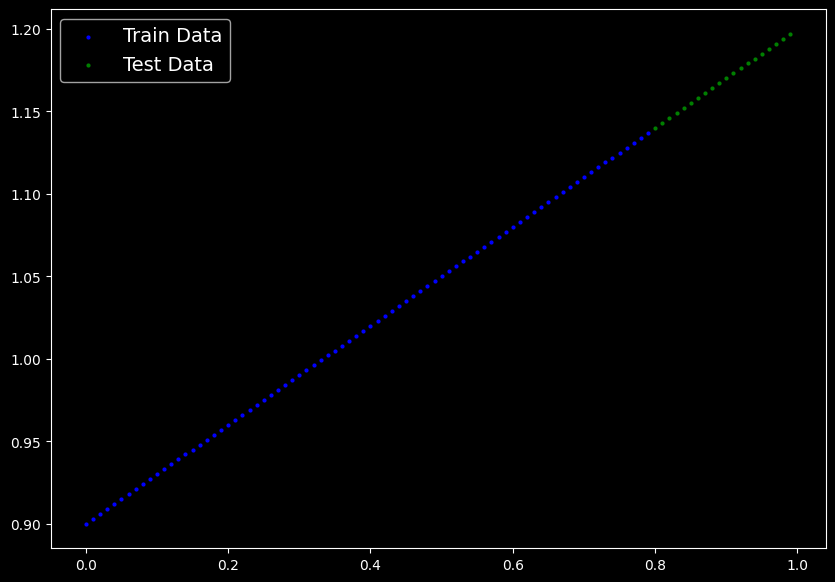

In [6]:
plot_predictions()

## 2. Build a PyTorch model by subclassing `nn.Module`. 
  * Inside should be a randomly initialized `nn.Parameter()` with `requires_grad=True`, one for `weights` and one for `bias`. 
  * Implement the `forward()` method to compute the linear regression function you used to create the dataset in 1. 
  * Once you've constructed the model, make an instance of it and check its `state_dict()`.
  * **Note:** If you'd like to use `nn.Linear()` instead of `nn.Parameter()` you can.

In [7]:
# Create PyTorch linear regression model by subclassing nn.Module
# Let's set the seed
torch.manual_seed(42)


class LinearRegressionTestModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(
            data=torch.randn(1, requires_grad=True, dtype=torch.float)
        )
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

In [8]:
# Instantiate the model and put it to the target device
test_lr_model = LinearRegressionTestModel()
test_lr_model.to(DEVICE)

test_lr_model


LinearRegressionTestModel()

In [9]:
# Let's pritn the state_dict
test_lr_model.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [10]:
test_lr_model.eval()
with torch.inference_mode():
    predictions_before_training = test_lr_model(X_test)

In [11]:
predictions_before_training, y_test

(tensor([0.3982, 0.4015, 0.4049, 0.4083, 0.4116, 0.4150, 0.4184, 0.4217, 0.4251,
         0.4285, 0.4318, 0.4352, 0.4386, 0.4419, 0.4453, 0.4487, 0.4520, 0.4554,
         0.4588, 0.4621]),
 tensor([1.1400, 1.1430, 1.1460, 1.1490, 1.1520, 1.1550, 1.1580, 1.1610, 1.1640,
         1.1670, 1.1700, 1.1730, 1.1760, 1.1790, 1.1820, 1.1850, 1.1880, 1.1910,
         1.1940, 1.1970]))

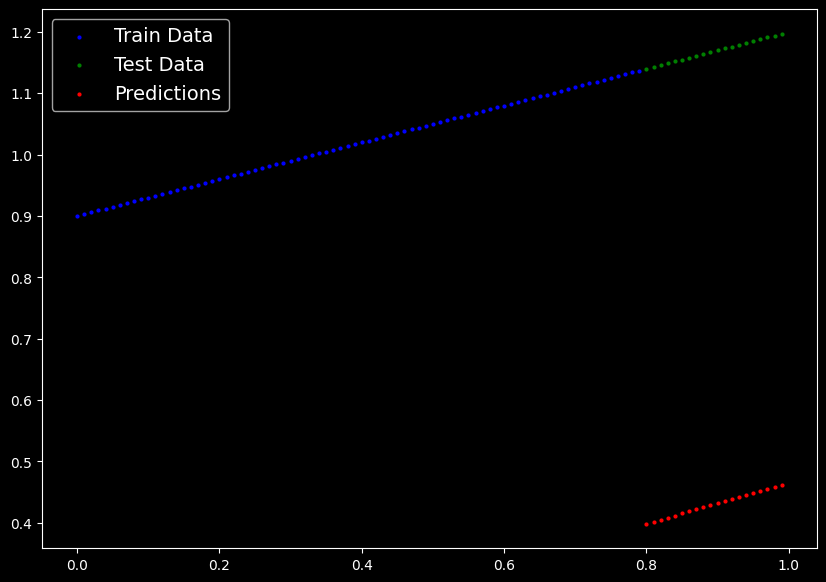

In [12]:
plot_predictions(predictions=predictions_before_training)

## 3. Create a loss function and optimizer using `nn.L1Loss()` and `torch.optim.SGD(params, lr)` respectively. 
  * Set the learning rate of the optimizer to be 0.01 and the parameters to optimize should be the model parameters from the model you created in 2.
  * Write a training loop to perform the appropriate training steps for 300 epochs.
  * The training loop should test the model on the test dataset every 20 epochs.

In [13]:
# Create the loss function and optimizer
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=test_lr_model.parameters(), lr=0.01)


In [14]:
# Training loop
# Train model for 300 epochs
NUM_EPOCHS = 300

# Set up the tracking of metrics
epoch_count = []
train_loss_count = []
test_loss_count = []
# Send data to target device
X_train.to(DEVICE)
X_test.to(DEVICE)
y_train.to(DEVICE)
y_test.to(DEVICE)

for epoch in range(NUM_EPOCHS):
    ### Training

    # Put model in train mode
    test_lr_model.train()

    # 1. Forward pass
    y_pred_train = test_lr_model(X_train)

    # 2. Calculate loss
    train_loss = loss_fn(y_pred_train, y_train)

    # 3. Zero gradients
    optimizer.zero_grad()

    # 4. Backpropagation
    train_loss.backward()

    # 5. Step the optimizer
    optimizer.step()

    ### Perform testing every 20 epochs
    if epoch % 20 == 0:
        # Put model in evaluation mode and setup inference context
        test_lr_model.eval()

        with torch.inference_mode():
            # 1. Forward pass
            y_pred_test = test_lr_model(X_test)

            # 2. Calculate test loss
            test_loss = loss_fn(y_pred_test, y_test)

        # Print out what's happening
        print(
            f"Epoch: {epoch} | Train loss: {train_loss:.3f} | Test loss: {test_loss:.3f}"
        )

        # Track the metrics
        epoch_count.append(epoch)
        train_loss_count.append(train_loss.item())
        test_loss_count.append(test_loss.item())

        # Print the state_dict
        print(f"Model's State Dict : {test_lr_model.state_dict()}")

Epoch: 0 | Train loss: 0.757 | Test loss: 0.725
Model's State Dict : OrderedDict([('weights', tensor([0.3406])), ('bias', tensor([0.1388]))])
Epoch: 20 | Train loss: 0.525 | Test loss: 0.454
Model's State Dict : OrderedDict([('weights', tensor([0.4196])), ('bias', tensor([0.3388]))])
Epoch: 40 | Train loss: 0.294 | Test loss: 0.183
Model's State Dict : OrderedDict([('weights', tensor([0.4986])), ('bias', tensor([0.5388]))])
Epoch: 60 | Train loss: 0.077 | Test loss: 0.073
Model's State Dict : OrderedDict([('weights', tensor([0.5712])), ('bias', tensor([0.7301]))])
Epoch: 80 | Train loss: 0.053 | Test loss: 0.116
Model's State Dict : OrderedDict([('weights', tensor([0.5570])), ('bias', tensor([0.7858]))])
Epoch: 100 | Train loss: 0.046 | Test loss: 0.105
Model's State Dict : OrderedDict([('weights', tensor([0.5244])), ('bias', tensor([0.8038]))])
Epoch: 120 | Train loss: 0.039 | Test loss: 0.089
Model's State Dict : OrderedDict([('weights', tensor([0.4906])), ('bias', tensor([0.8188]))]

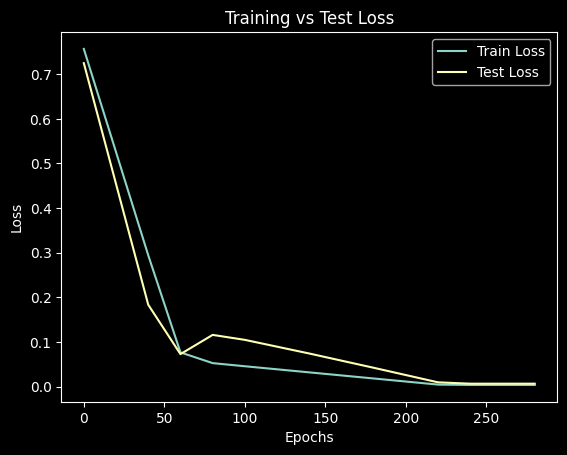

In [15]:
plt.plot(epoch_count, train_loss_count, label="Train Loss")
plt.plot(epoch_count, test_loss_count, label="Test Loss")
plt.title("Training vs Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

## 4. Make predictions with the trained model on the test data.
  * Visualize these predictions against the original training and testing data (**note:** you may need to make sure the predictions are *not* on the GPU if you want to use non-CUDA-enabled libraries such as matplotlib to plot).

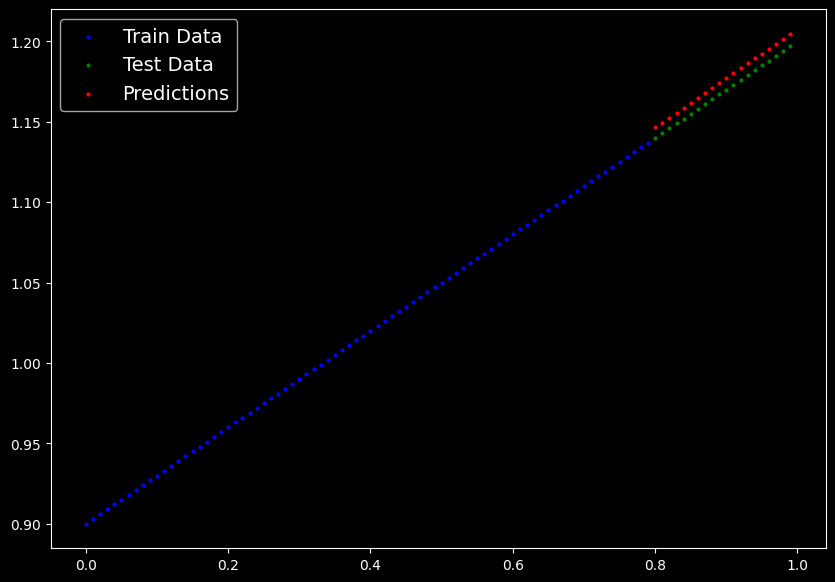

In [16]:
# Make predictions with the model
test_lr_model.eval()
with torch.inference_mode():
    test_predictions = test_lr_model(X_test)

plot_predictions(predictions=test_predictions)


## 5. Save your trained model's `state_dict()` to file.
  * Create a new instance of your model class you made in 2. and load in the `state_dict()` you just saved to it.
  * Perform predictions on your test data with the loaded model and confirm they match the original model predictions from 4.

In [17]:
from pathlib import Path

# 1. Create models directory
MODEL_FILE_PATH = Path("../models")
MODEL_FILE_PATH.mkdir(parents=True, exist_ok=True)
MODEL_NAME = "exercise_lr_model.pth"

# 2. Create model save path
MODEL_SAVE_PATH = MODEL_FILE_PATH / MODEL_NAME

# 3. Save the model state dict
torch.save(obj=test_lr_model.state_dict(), f=MODEL_SAVE_PATH)
print(f"Test model saved to : {MODEL_SAVE_PATH}")


Test model saved to : ..\models\exercise_lr_model.pth


In [18]:
# Create new instance of model and load saved state dict (make sure to put it on the target device)
loaded_model = LinearRegressionTestModel()
print(f"State dict before loading the trained state_dict : {loaded_model.state_dict()}")

loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH))
print(f"State dict after loading the trained state_dict : {loaded_model.state_dict()}")

State dict before loading the trained state_dict : OrderedDict([('weights', tensor([0.2345])), ('bias', tensor([0.2303]))])
State dict after loading the trained state_dict : OrderedDict([('weights', tensor([0.3067])), ('bias', tensor([0.9011]))])


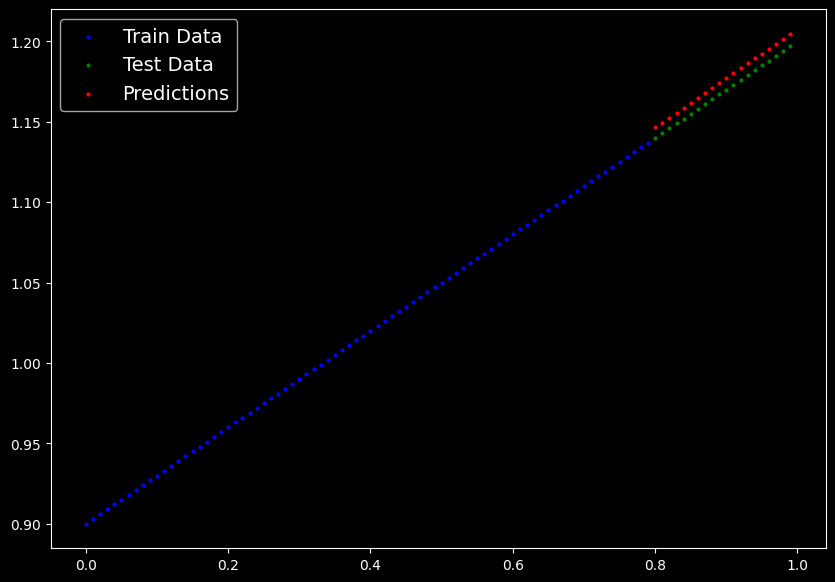

In [19]:
# Make predictions with loaded model and compare them to the previous
loaded_model.eval()
with torch.inference_mode():
    loaded_model_pred = loaded_model(X_test)

plot_predictions(predictions=loaded_model_pred)

In [20]:
weight * 0.5 + bias

1.05

In [21]:
w = loaded_model.state_dict()["weights"]
b = loaded_model.state_dict()["bias"]
w, b

(tensor([0.3067]), tensor([0.9011]))

In [22]:
w * 0.5 + b

tensor([1.0544])